# Homogeneous Circle

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import torch as tn

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source
from ttnte.cad import Patch
from ttnte.cad.surfaces import circle
from ttnte.sources import IsotropicInternalSource

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 4096

# Get XS data
total = 1  # 1/cm
scattering_ratio = 0.9
xs_server = Server(
    {
        "Material": {
            "total": np.array([total]),
            "scatter_gtg": np.array([[[total * scattering_ratio]]]),
        }
    }
)

In [3]:
rc = 5 # Critical radius (cm)
patch = Patch(circle(rc), "Material")

# Create mesh
mesh = IGAMesh()
mesh.add_patch(patch)

# Add uniform source of 1/cm to patch
source = IsotropicInternalSource(np.ones((1, *patch.shape)))
patch.set_source(source)

# Refine mesh resolution
mesh.refine(factor=13, degree=3)

# Connect patches
mesh.connect()

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=1, reflective_boundaries=False)
  -> Patch(material=Material, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7e65f66d5a00>, id=0, name=None, shape=(16, 16), backend=geomdl)

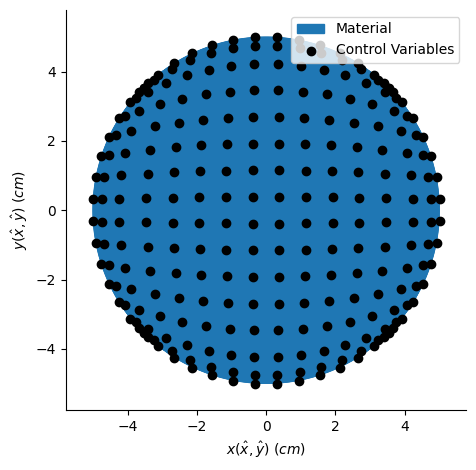

In [4]:
# Plot final mesh
ax = mesh.plot()
plt.tight_layout()
plt.savefig("./figs/circle.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [5]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save TT information
assembler.save_info("./coo_info.csv")

## Create operators in COO format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info.csv")

Running MatrixAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, q, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 18.88 s)
Step            Ranks                     Compression
H               1048576,1048576              8947.85
S               1,256,256                       1.64
q               1048576                         1.00
B_out           1048576,1048576            420100.27
Running TTAssembler.build()
Discretization: N = 4096, G = 1, P = 1, A = 16, B = 16
Operators: H, S, B_out
---------------------------------------------------------------------------


  0%|          | 0/1 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 17.44 s)
Step            Ranks                     Compression
H               3,3,3,56                  14500839.15
S               1,1,1,18                  97474435.09
B_out           4,66,106,58                121856.01


## Solve

In [6]:
# Run fixed source calculation
psi = fixed_source(
    T=LinearOperator([tts.H, mats.B_out, -mats.S], N=assembler.N, M=assembler.M),
    q=mats.q,
    device=0,
    max_iters=30,
    tol=1e-8,
    restarts=250,
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi.unsqueeze(3))

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

GMRES Finished
Elapsed Time: 50.63603949546814


## Plot and Compare to OpenMC

<Figure size 640x480 with 0 Axes>

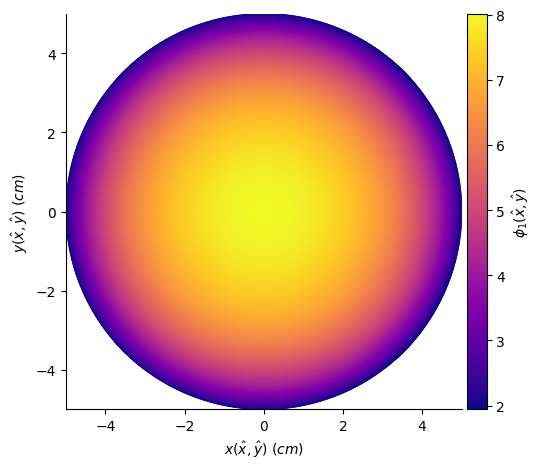

In [7]:
# Set flux
mesh.set_phi(phi)

# Plot
plt.clf()
ax, cbar = mesh.plot(plot_ctrlpts=False)
cbar.set_label("$\\phi_1(\\hat{x}, \\hat{y})$")
plt.tight_layout()
plt.savefig("./figs/phi_1.png", dpi=300)
plt.show()

In [8]:
leakage_frac_openmc = [0.354235, 2.173568e-05]

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = round(float(leakage / production), 5)
print(leakage_frac)
print("Leakage fraction error: {} -/+ {}".format(
    leakage_frac - leakage_frac_openmc[0], leakage_frac_openmc[1])
)

0.43996
Leakage fraction error: 0.085725 -/+ 2.173568e-05
